# 🔎 Exploratory Data Analysis — Customer Churn

A thorough, narrated EDA of the **IBM Telco Customer Churn** dataset. Every chart renders inline so this notebook is a self-contained data story, and the statistical tests reuse the project's production `src/analysis/eda.py` module.

**Contents**
1. Setup & data loading
2. Data quality audit (missingness, types, duplicates)
3. Target overview (class balance)
4. Numeric features vs churn
5. Categorical features vs churn
6. Correlations & multicollinearity
7. Statistical significance & effect sizes (the honest ranking of drivers)
8. Tenure & contract deep-dive
9. Key takeaways for modeling

> Generated PNGs are also written to `reports/figures/eda_notebook/` so they can be embedded in a slide deck or the README.

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
PALETTE = ['#2c7fb8', '#de2d26']  # retained, churned
pd.set_option('display.max_columns', 60)

from src.utils import load_config, set_global_seed, ensure_dir
from src.data.make_dataset import get_raw_data
from src.data.preprocess import clean_data
from src.features.build_features import add_engineered_features

config = load_config('../config.yaml')
set_global_seed(config['project']['random_seed'])
TARGET = config['data']['target_column']

# Where to save figures produced by this notebook (ensure_dir anchors to the
# project root, so we pass a root-relative path — no leading '../').
FIG_DIR = ensure_dir('reports/figures/eda_notebook')

def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(str(FIG_DIR), name), dpi=130, bbox_inches='tight')

print('Config loaded for:', config['project']['name'])

Config loaded for: Customer Churn Prediction & Retention Analytics


In [2]:
# Raw data (real Telco download, or synthetic fallback with identical schema)
raw = get_raw_data(config)
print('Raw shape:', raw.shape)
raw.head()

00:50:58 | INFO    | data | Using cached raw data at /Users/tantheta/Customer Churn Prediction & Retention Analytics/data/raw/telco_churn.csv


Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data quality audit
Before any analysis we check structure, types, missing values, and duplicates. The famous Telco gotcha: `TotalCharges` is stored as text and has blanks for brand-new (tenure = 0) customers.

In [3]:
print('Shape:', raw.shape)
print('\nDtypes:')
print(raw.dtypes)
print('\nDuplicate rows:', raw.duplicated().sum())
print('Duplicate customerIDs:', raw['customerID'].duplicated().sum() if 'customerID' in raw.columns else 'n/a')

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Duplicate rows: 0
Duplicate customerIDs: 0


In [4]:
# Missing / blank audit (TotalCharges blanks hide as whitespace strings)
tc = pd.to_numeric(raw['TotalCharges'], errors='coerce') if 'TotalCharges' in raw.columns else None
miss = pd.DataFrame({
    'n_missing': raw.isna().sum(),
    'pct_missing': (raw.isna().mean() * 100).round(2),
})
if tc is not None:
    print('Blank/non-numeric TotalCharges values:', int(tc.isna().sum()))
miss[miss['n_missing'] > 0]

Blank/non-numeric TotalCharges values: 11


,n_missing,pct_missing


In [5]:
# Apply the project's cleaning + feature engineering and confirm the fix
cleaned = clean_data(raw, config)
df = add_engineered_features(cleaned)
print('Cleaned shape:', cleaned.shape, '| With engineered features:', df.shape)
print('TotalCharges dtype now:', df['TotalCharges'].dtype, '| NaNs:', int(df['TotalCharges'].isna().sum()))
print('Target encoded as:', sorted(df[TARGET].unique()))
df.describe(include='all').T.head(25)

00:50:58 | INFO    | preprocess | Filled 11 missing TotalCharges (tenure==0 customers).


00:50:58 | INFO    | preprocess | Cleaned data: 7043 rows, 21 columns.


00:50:58 | INFO    | features | Added engineered features -> total columns: 30


Cleaned shape: (7043, 21) | With engineered features: (7043, 30)
TotalCharges dtype now: float64 | NaNs: 0
Target encoded as: [np.int64(0), np.int64(1)]


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Target overview — class balance
Churn is the minority class (~26%). This imbalance is *the* reason we later prefer PR-AUC over accuracy and tune the decision threshold.

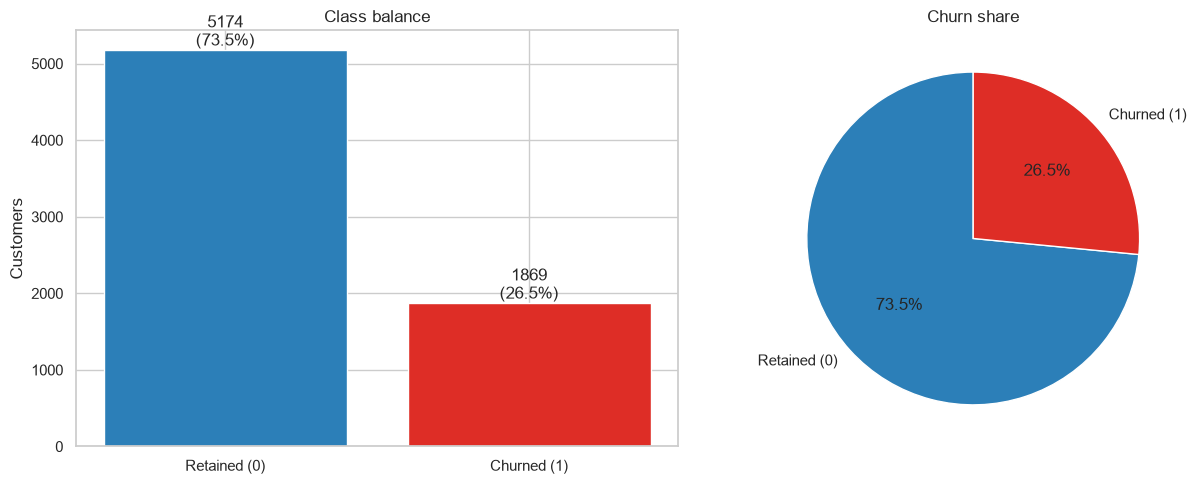

Overall churn rate: 26.54%


In [6]:
counts = df[TARGET].value_counts().sort_index()
labels = ['Retained (0)', 'Churned (1)']
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(labels, counts.values, color=PALETTE)
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f'{v}\n({v/len(df):.1%})', ha='center', va='bottom')
ax[0].set_title('Class balance')
ax[0].set_ylabel('Customers')
ax[1].pie(counts.values, labels=labels, autopct='%1.1f%%', colors=PALETTE,
          startangle=90, wedgeprops={'edgecolor': 'white'})
ax[1].set_title('Churn share')
savefig('target_balance.png'); plt.show()
print(f'Overall churn rate: {df[TARGET].mean():.2%}')

## 4. Numeric features vs churn
The three core numeric drivers are **tenure**, **MonthlyCharges**, and **TotalCharges**. We compare their distributions across churned vs retained customers.

/var/folders/_q/k5dsc4z11nd9695gqkp8hnf00000gn/T/ipykernel_78732/2723849004.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[TARGET].map({0:'Retained',1:'Churned'}), y=df[col],


/var/folders/_q/k5dsc4z11nd9695gqkp8hnf00000gn/T/ipykernel_78732/2723849004.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[TARGET].map({0:'Retained',1:'Churned'}), y=df[col],
/var/folders/_q/k5dsc4z11nd9695gqkp8hnf00000gn/T/ipykernel_78732/2723849004.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[TARGET].map({0:'Retained',1:'Churned'}), y=df[col],


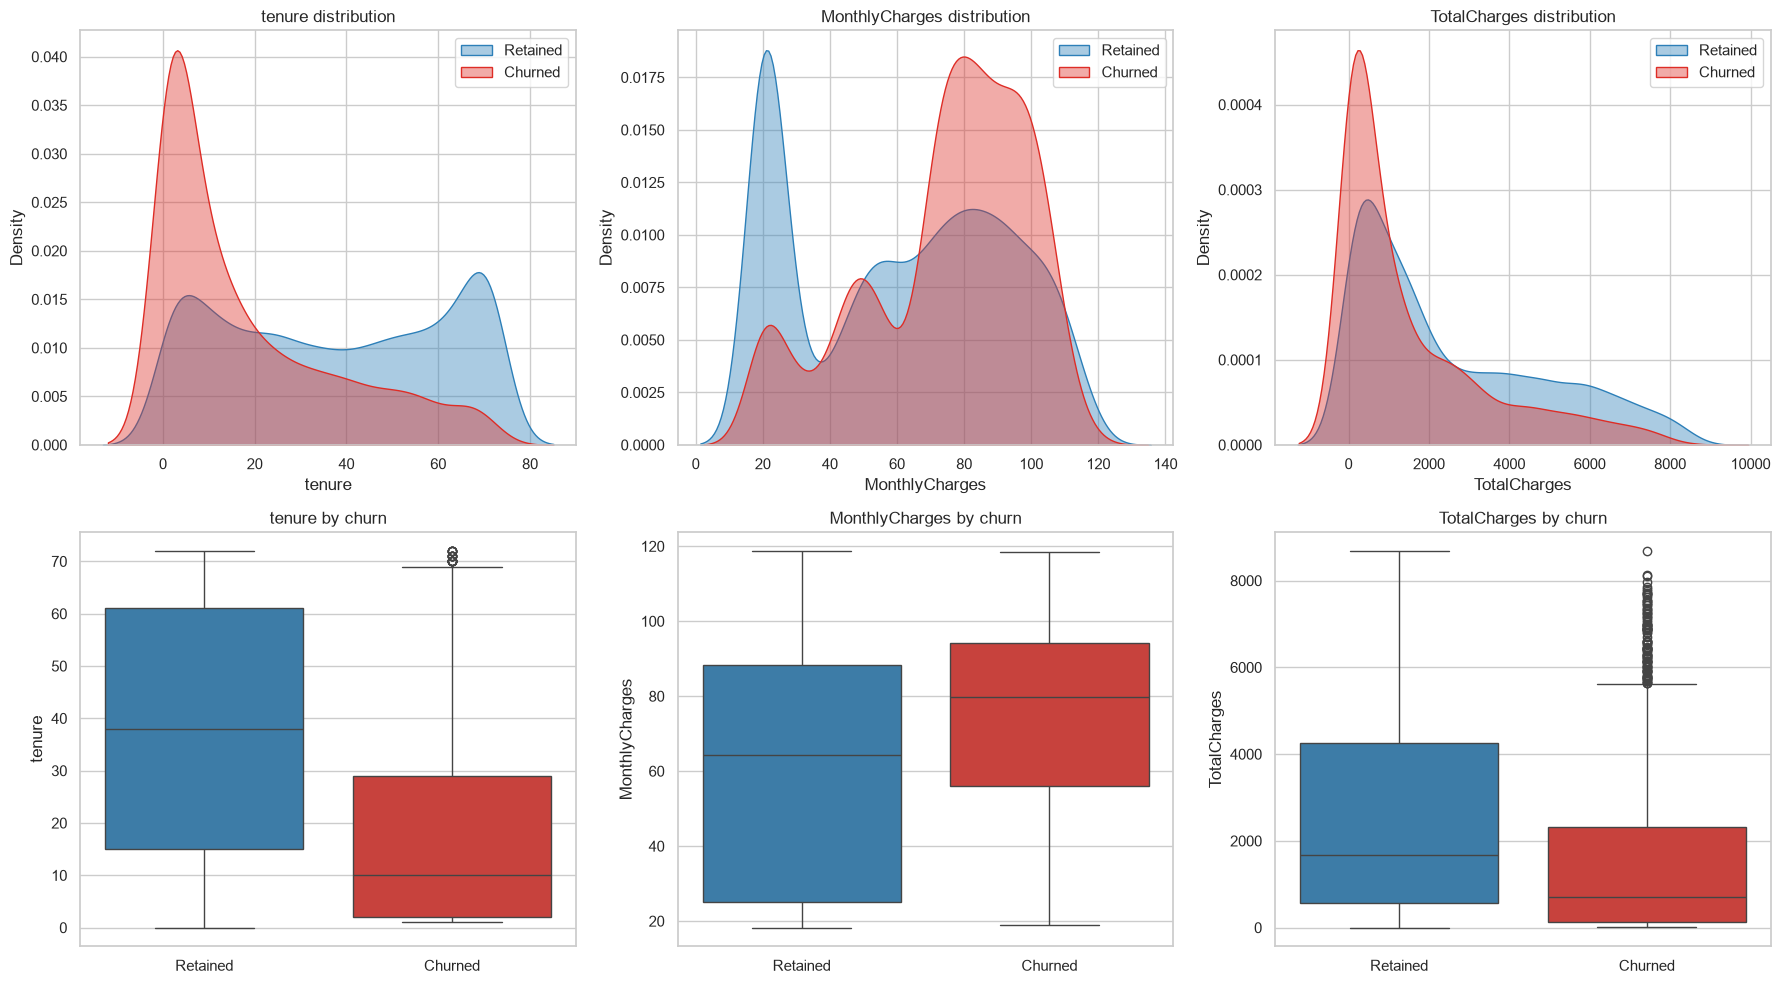

In [7]:
num_cols = [c for c in ['tenure', 'MonthlyCharges', 'TotalCharges'] if c in df.columns]
fig, axes = plt.subplots(2, len(num_cols), figsize=(6*len(num_cols), 10))
for j, col in enumerate(num_cols):
    # KDE by class
    for cls, color, lab in zip([0, 1], PALETTE, ['Retained', 'Churned']):
        sns.kdeplot(df.loc[df[TARGET]==cls, col], ax=axes[0, j], fill=True,
                    alpha=0.4, color=color, label=lab)
    axes[0, j].set_title(f'{col} distribution'); axes[0, j].legend()
    # Boxplot by class
    sns.boxplot(x=df[TARGET].map({0:'Retained',1:'Churned'}), y=df[col],
                ax=axes[1, j], palette=PALETTE)
    axes[1, j].set_title(f'{col} by churn'); axes[1, j].set_xlabel('')
savefig('numeric_vs_churn.png'); plt.show()

/var/folders/_q/k5dsc4z11nd9695gqkp8hnf00000gn/T/ipykernel_78732/1776524697.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ten = df.groupby('_tenure_bin')[TARGET].mean()
/var/folders/_q/k5dsc4z11nd9695gqkp8hnf00000gn/T/ipykernel_78732/1776524697.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chg = df.groupby('_charge_bin')[TARGET].mean()


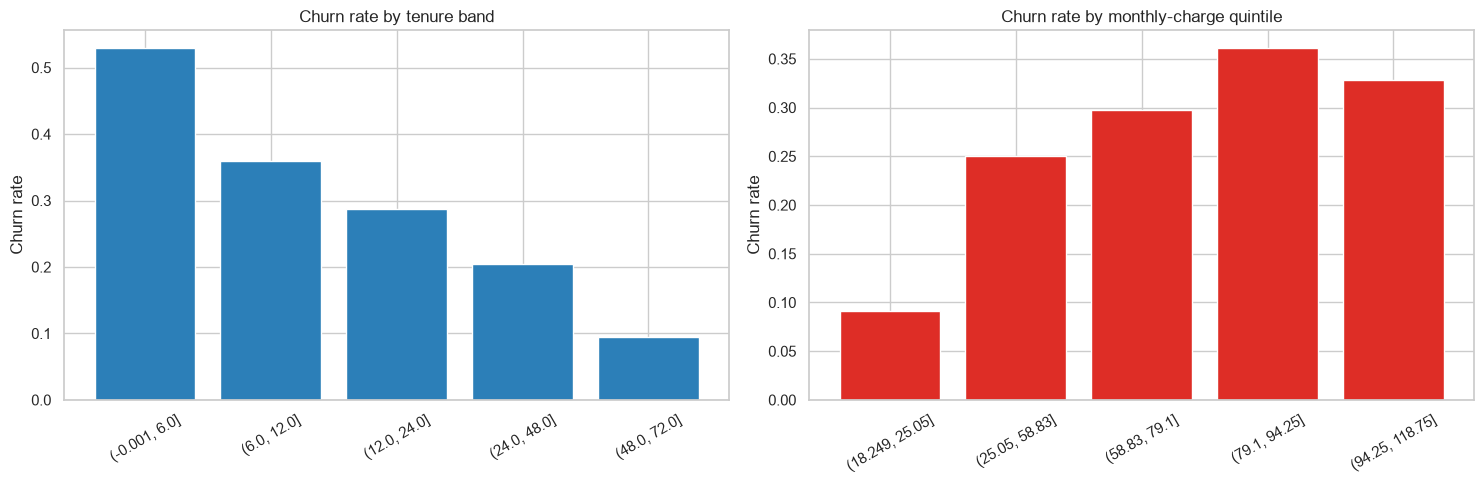

In [8]:
# Churn rate across binned tenure and monthly charges — a clear monotonic story
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df['_tenure_bin'] = pd.cut(df['tenure'], bins=[0,6,12,24,48,72], include_lowest=True)
ten = df.groupby('_tenure_bin')[TARGET].mean()
axes[0].bar(ten.index.astype(str), ten.values, color='#2c7fb8')
axes[0].set_title('Churn rate by tenure band'); axes[0].set_ylabel('Churn rate')
axes[0].tick_params(axis='x', rotation=30)
df['_charge_bin'] = pd.qcut(df['MonthlyCharges'], q=5, duplicates='drop')
chg = df.groupby('_charge_bin')[TARGET].mean()
axes[1].bar(chg.index.astype(str), chg.values, color='#de2d26')
axes[1].set_title('Churn rate by monthly-charge quintile'); axes[1].set_ylabel('Churn rate')
axes[1].tick_params(axis='x', rotation=30)
savefig('churn_rate_by_bins.png'); plt.show()
df.drop(columns=['_tenure_bin','_charge_bin'], inplace=True)

**Reading it:** churn is heavily concentrated in **low-tenure, high-monthly-charge** customers — new, expensive customers are the flight risk. Tenure has a strong, monotonic protective effect.

## 5. Categorical features vs churn
We plot churn rate for each category level, sorted, so the riskiest segments jump out.

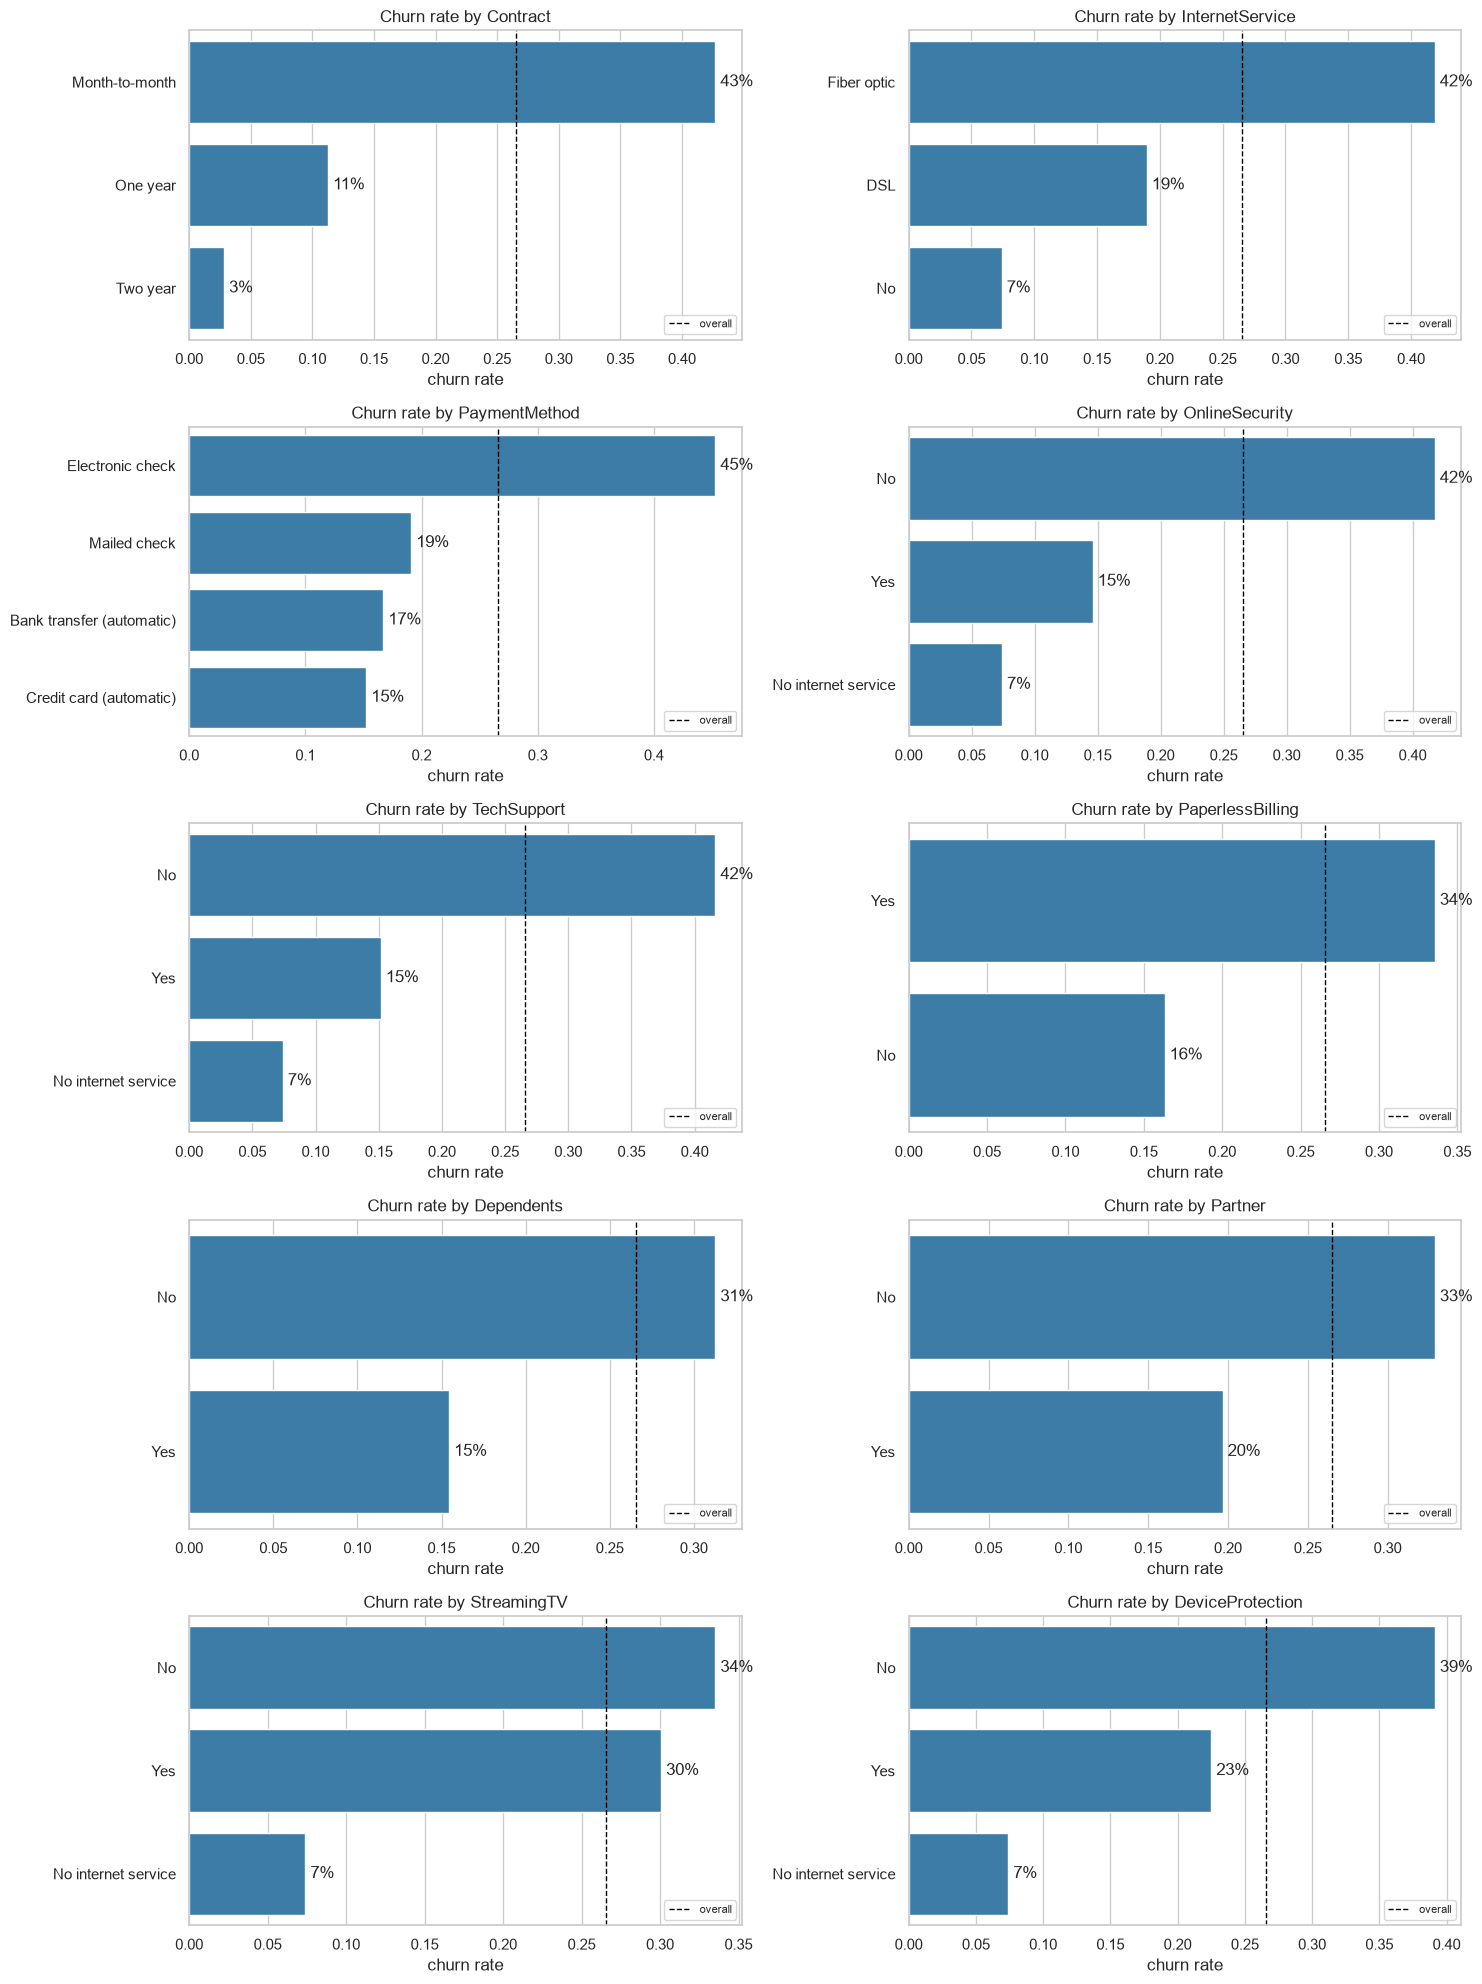

In [9]:
cat_cols = [c for c in df.columns if df[c].dtype == object and c not in [config['data']['id_column']]]
# focus on the original business categoricals
focus = [c for c in ['Contract','InternetService','PaymentMethod','OnlineSecurity',
                     'TechSupport','PaperlessBilling','Dependents','Partner',
                     'StreamingTV','DeviceProtection'] if c in cat_cols]
n = len(focus); ncols = 2; nrows = int(np.ceil(n/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, focus):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index.astype(str), ax=ax, color='#2c7fb8')
    ax.axvline(df[TARGET].mean(), color='black', ls='--', lw=1, label='overall')
    for i, v in enumerate(rate.values):
        ax.text(v, i, f' {v:.0%}', va='center')
    ax.set_title(f'Churn rate by {col}'); ax.set_xlabel('churn rate'); ax.set_ylabel('')
    ax.legend(loc='lower right', fontsize=8)
for ax in axes[len(focus):]:
    ax.set_visible(False)
savefig('categorical_vs_churn.png'); plt.show()

**Reading it:** month-to-month contracts, fiber-optic internet, electronic-check payment, and the absence of online security / tech support all push churn well above the ~26% baseline (dashed line).

## 6. Correlations & multicollinearity
Numeric correlation heatmap. Note that `tenure`, `MonthlyCharges`, and `TotalCharges` are mechanically related (Total ≈ tenure × Monthly) — useful to know before linear modeling.

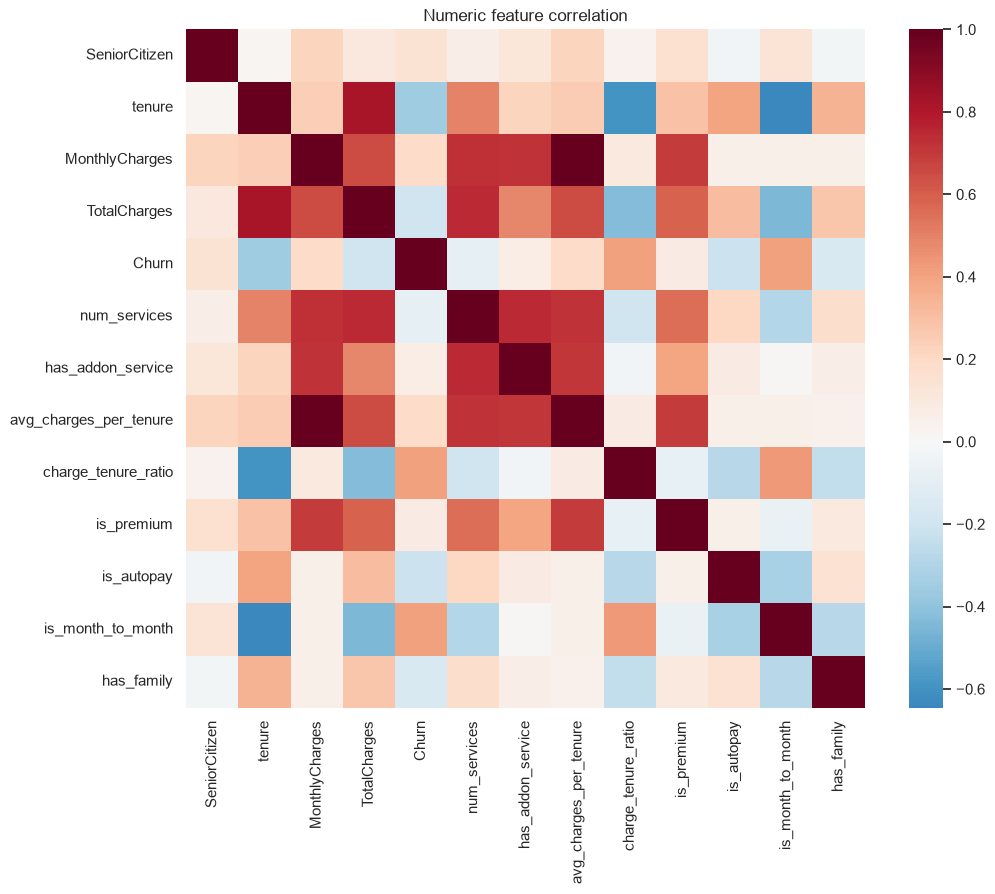

Top correlations with the churn target:
charge_tenure_ratio       0.412
is_month_to_month         0.405
tenure                   -0.352
is_autopay               -0.210
TotalCharges             -0.198
MonthlyCharges            0.193
avg_charges_per_tenure    0.193
has_family               -0.163
SeniorCitizen             0.151
num_services             -0.088
Name: Churn, dtype: float64


In [10]:
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, square=True)
plt.title('Numeric feature correlation')
savefig('correlation_heatmap.png'); plt.show()

print('Top correlations with the churn target:')
print(corr[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False).head(10).round(3))

## 7. Statistical significance & effect sizes
Large samples make almost everything "significant", so we rank by **effect size** (Cramér's V for categoricals, Cohen's d for numerics) using the project's `run_eda`.

In [11]:
from src.analysis.eda import run_eda
eda = run_eda(df, TARGET)
cat_assoc = eda['categorical_association']
num_sig = eda['numeric_significance']
print('Categorical associations (ranked by Cramer\'s V):')
display(cat_assoc)
print('Numeric significance (ranked by |Cohen\'s d|):')
display(num_sig)

00:51:00 | INFO    | eda | Computed categorical associations for 17 features.


00:51:00 | INFO    | eda | Computed numeric significance for 12 features.


Categorical associations (ranked by Cramer's V):


,feature,chi2,p_value,cramers_v,significant_5pct
13,Contract,1184.596572,5.863038e-258,0.409798,True
16,tenure_group,927.329275,1.995934e-199,0.362101,True
7,OnlineSecurity,849.998968,2.661150e-185,0.347016,True
10,TechSupport,828.197068,1.443084e-180,0.342526,True
6,InternetService,732.309590,9.571788e-160,0.322037,True
15,PaymentMethod,648.142327,3.682355e-140,0.302677,True
8,OnlineBackup,601.812790,2.079759e-131,0.291850,True
9,DeviceProtection,558.419369,5.505219e-122,0.281095,True
12,StreamingMovies,375.661479,2.667757e-82,0.230351,True
11,StreamingTV,374.203943,5.528994e-82,0.229902,True


Numeric significance (ranked by |Cohen's d|):


,feature,mean_churned,mean_retained,t_stat,p_value,cohens_d,significant_5pct
10,is_month_to_month,0.885500,0.429068,45.275165,0.000000e+00,1.096641,True
1,tenure,17.979133,37.569965,-34.823819,1.195495e-232,-0.892829,True
7,charge_tenure_ratio,11.745880,3.612215,28.072868,2.189360e-148,0.861060,True
9,is_autopay,0.262172,0.497874,-19.125452,7.452631e-78,-0.500483,True
3,TotalCharges,1531.796094,2549.911442,-18.706618,5.902581e-75,-0.479840,True
2,MonthlyCharges,74.441332,61.265124,18.407527,8.592449e-73,0.469507,True
6,avg_charges_per_tenure,74.433154,61.181674,18.341982,2.749968e-72,0.468681,True
11,has_family,0.399144,0.583108,-13.891280,1.090604e-42,-0.374309,True
0,SeniorCitizen,0.254682,0.128721,11.343877,3.587587e-29,0.324101,True
4,num_services,1.768325,2.135292,-8.344319,9.555372e-17,-0.211103,True


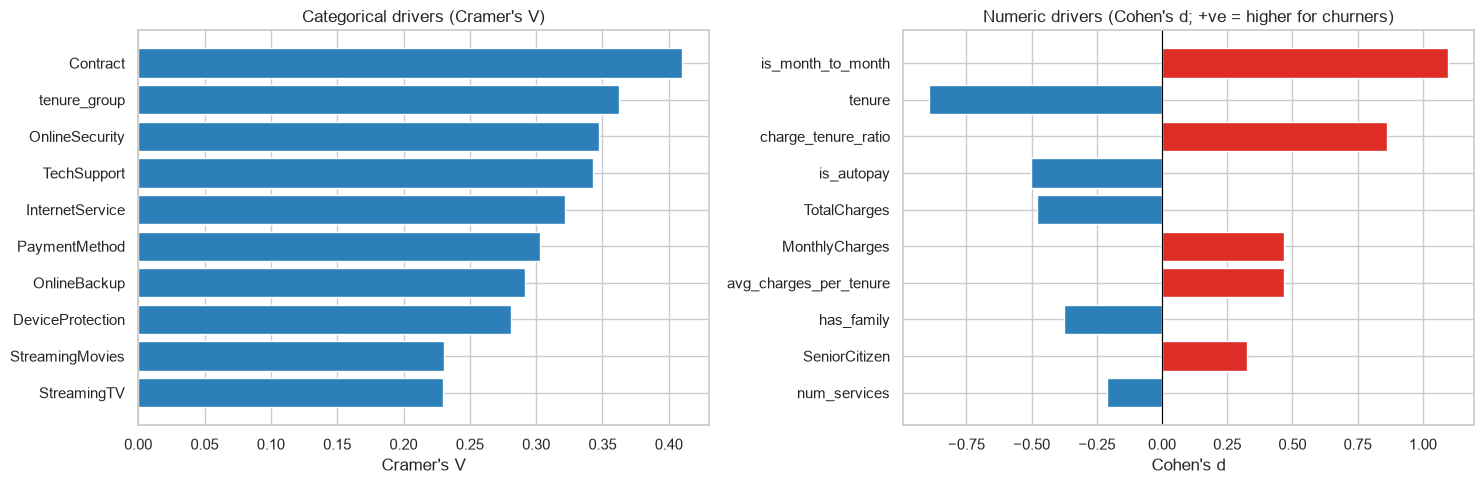

In [12]:
# Visualise the effect-size rankings
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_cat = cat_assoc.sort_values('cramers_v').tail(10)
axes[0].barh(top_cat['feature'], top_cat['cramers_v'], color='#2c7fb8')
axes[0].set_title("Categorical drivers (Cramer's V)"); axes[0].set_xlabel("Cramer's V")
ns = num_sig.copy(); ns['abs_d'] = ns['cohens_d'].abs()
ns = ns.sort_values('abs_d').tail(10)
colors = ['#de2d26' if d > 0 else '#2c7fb8' for d in ns['cohens_d']]
axes[1].barh(ns['feature'], ns['cohens_d'], color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title("Numeric drivers (Cohen's d; +ve = higher for churners)"); axes[1].set_xlabel("Cohen's d")
savefig('effect_sizes.png'); plt.show()

## 8. Tenure & contract deep-dive
Contract type is the single strongest categorical driver, and it interacts with tenure. This cross-tab heatmap of churn rate makes the interaction explicit.

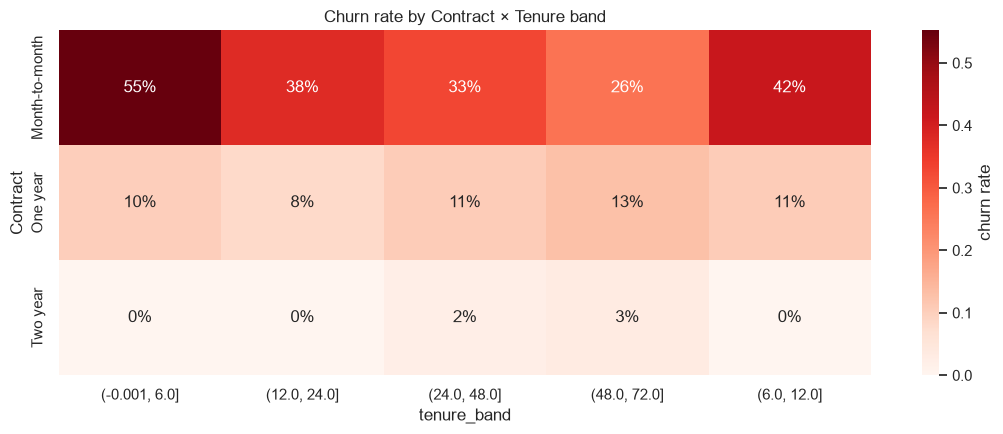

In [13]:
tmp = df.copy()
tmp['tenure_band'] = pd.cut(tmp['tenure'], bins=[0,6,12,24,48,72], include_lowest=True).astype(str)
pivot = tmp.pivot_table(index='Contract', columns='tenure_band', values=TARGET, aggfunc='mean')
plt.figure(figsize=(11, 4.5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='Reds', cbar_kws={'label':'churn rate'})
plt.title('Churn rate by Contract × Tenure band')
savefig('contract_tenure_heatmap.png'); plt.show()

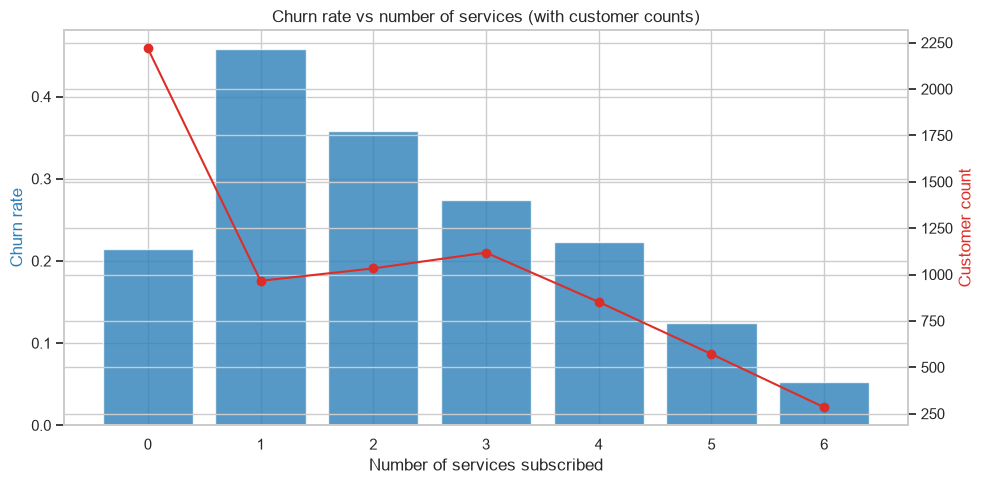

In [14]:
# Number of add-on services vs churn (engineered feature)
if 'num_services' in df.columns:
    svc = df.groupby('num_services')[TARGET].agg(['mean','count'])
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.bar(svc.index, svc['mean'], color='#2c7fb8', alpha=0.8)
    ax1.set_xlabel('Number of services subscribed'); ax1.set_ylabel('Churn rate', color='#2c7fb8')
    ax2 = ax1.twinx(); ax2.plot(svc.index, svc['count'], color='#de2d26', marker='o')
    ax2.set_ylabel('Customer count', color='#de2d26')
    plt.title('Churn rate vs number of services (with customer counts)')
    savefig('services_vs_churn.png'); plt.show()

## 9. Key takeaways for modeling

- **Class imbalance (~26% churn)** → use PR-AUC, class weighting/SMOTE, and a tuned decision threshold (not 0.5).
- **Strongest drivers:** Contract type, tenure, internet service (fiber), payment method (electronic check), and lack of online security / tech support.
- **Risk profile:** new + high-monthly-charge + month-to-month customers are the flight risk; long tenure and longer contracts are protective.
- **Multicollinearity:** `TotalCharges ≈ tenure × MonthlyCharges` — fine for tree models, worth noting for linear ones (we standardize + regularize).
- **More services → lower churn**, supporting a bundling/lock-in retention lever.

All figures from this notebook are saved in `reports/figures/eda_notebook/`. Continue to `01_churn_analysis_walkthrough.ipynb` for the modeling, profit optimisation, and retention strategy.